**# Berlin Housing Price Analysis**
### **Loads the dataset, cleans it, treats outliers, engineers a few features,**
# then looks at what drives price (sqft_total and living area).

Loaded with encoding='utf-8', sep=','
Shape: (9999, 11)
      price  bedrooms  bathrooms  sqft_living  sqft_total  floors  condition  \
0  221900.0       3.0        1.0          NaN      5650.0     1.0        3.0   
1  538000.0       3.0        NaN       2570.0      7242.0     2.0        3.0   
2  180000.0       2.0        1.0          NaN     10000.0     1.0        3.0   
3  604000.0       4.0        3.0       1960.0      5000.0     1.0        5.0   
4  510000.0       3.0        2.0       1680.0      8080.0     1.0        3.0   

   grade   built  renovated  living_area_sqft  
0      7  1955.0          0            1340.0  
1      7  1951.0       1991            1690.0  
2      6  1933.0          0               NaN  
3      7  1965.0          0            1360.0  
4      8  1987.0          0               NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------          

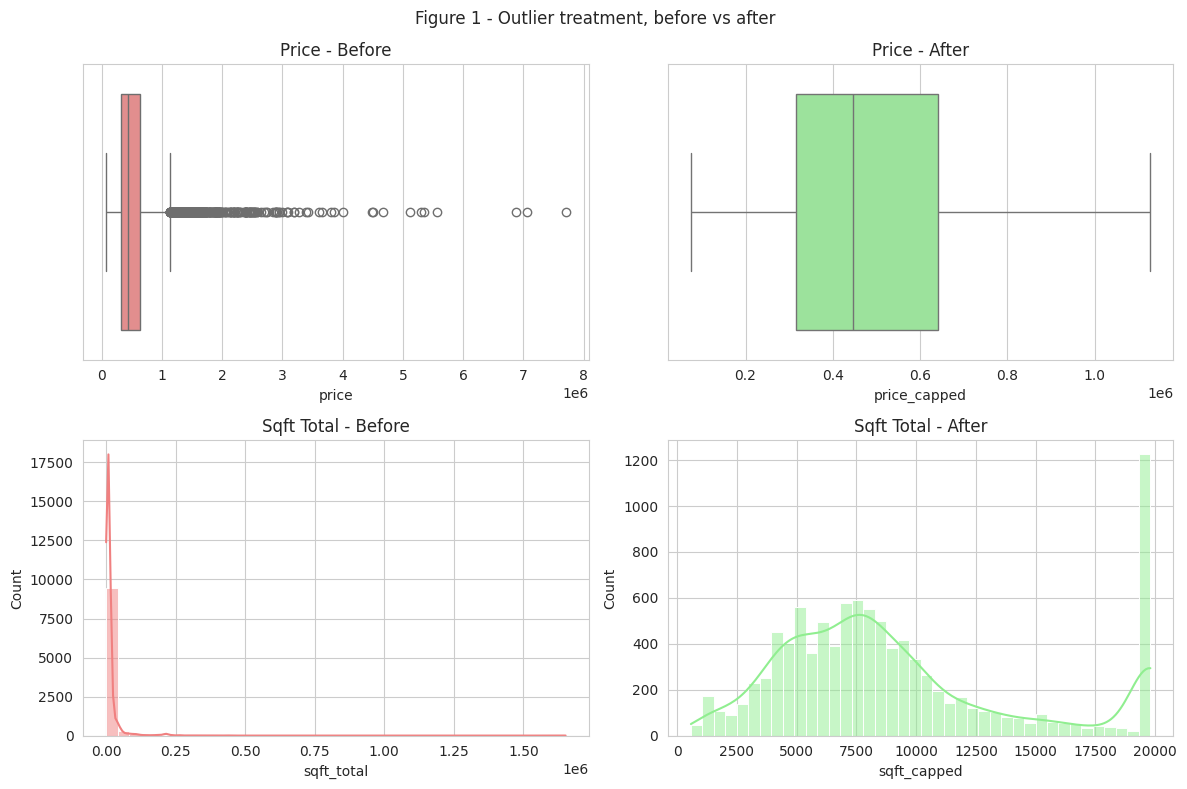


Final cleaned dataset: (9988, 19)

Price vs sqft_total: r = 0.178, p = 7.39e-72, significant: True


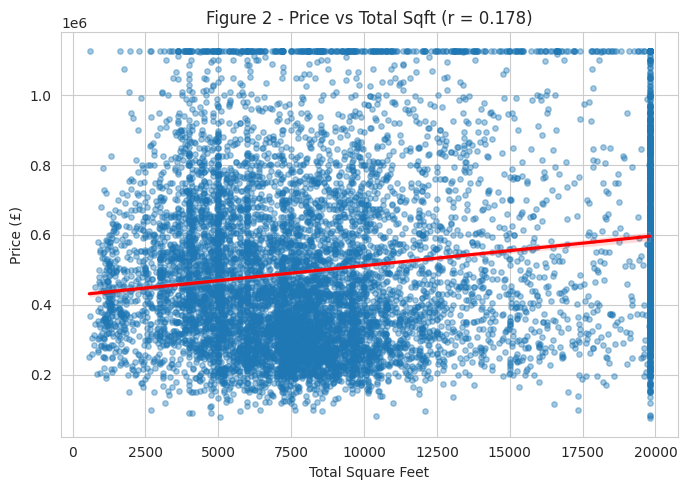

Price vs living_area: r = 0.636, p = 0.00e+00, significant: True


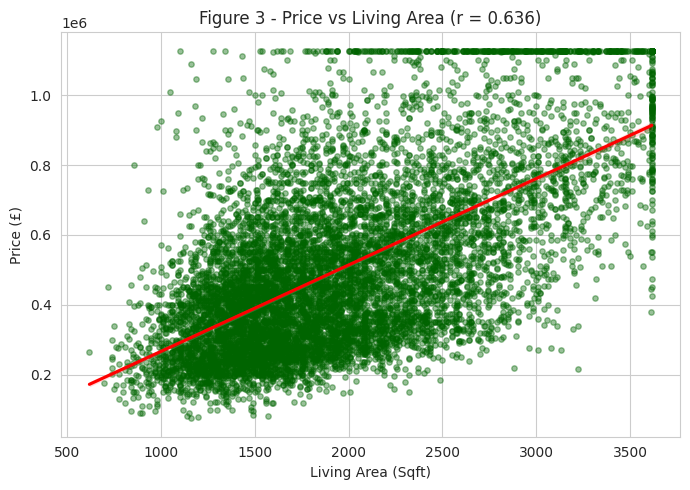


Saved cleaned data. Final shape: (9988, 19)


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_style("whitegrid")

DATA_PATH = '/content/BerlinHousing4049.csv'
OUTPUT_DIR = '/mnt/user-data/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Load data and take a first look ---
df = None
for enc in ['utf-8', 'latin1', 'cp1252']:
    for sep in [',', ';', '\t']:
        try:
            candidate = pd.read_csv(DATA_PATH, encoding=enc, sep=sep)
            if candidate.shape[1] > 1:  # a real table, not everything crammed into 1 column
                df = candidate
                print(f"Loaded with encoding='{enc}', sep='{sep}'")
                break
        except (UnicodeDecodeError, pd.errors.ParserError):
            continue
    if df is not None:
        break

if df is None:
    # last resort: let pandas auto-detect the separator
    df = pd.read_csv(DATA_PATH, sep=None, engine='python', encoding='latin1')
    print("Loaded with auto-detected separator (engine='python')")
print("Shape:", df.shape)
print(df.head())
print(df.info())
print("\nDuplicated rows:", df.duplicated().sum())
print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe (price):\n", df['price'].describe())
print("Skewness - price:", round(df['price'].skew(), 2), "| sqft_total:", round(df['sqft_total'].skew(), 2))

# --- Cleaning ---
df_clean = df.drop_duplicates().copy()

# price is our target variable, so rows missing it aren't usable
df_clean = df_clean.dropna(subset=['price'])

# median imputation for numeric fields, mode for the categorical one
for col in ['bedrooms', 'bathrooms', 'sqft_total', 'built']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
df_clean['condition'] = df_clean['condition'].fillna(df_clean['condition'].mode()[0])

# sqft_living and living_area_sqft measure almost the same thing, so combine
# them into one "best available" column instead of imputing separately
df_clean['living_area'] = df_clean['living_area_sqft'].fillna(df_clean['sqft_living'])
df_clean['living_area'] = df_clean['living_area'].fillna(df_clean['living_area'].median())

print("\nMissing values remaining after cleaning:", df_clean.isnull().sum().sum())

# --- Outlier detection and treatment (IQR method) ---
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col, new_col in [('price', 'price_capped'), ('sqft_total', 'sqft_capped'), ('living_area', 'living_capped')]:
    lower, upper = iqr_bounds(df_clean[col])
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"{col}: bounds [{lower:,.0f}, {upper:,.0f}], outliers: {outliers} ({outliers/len(df_clean)*100:.1f}%)")
    df_clean[new_col] = df_clean[col].clip(lower, upper)  # winsorize rather than drop, to keep the data

print("\nSkewness after capping - price:", round(df_clean['price_capped'].skew(), 2),
      "| sqft_total:", round(df_clean['sqft_capped'].skew(), 2))

# Boxplots + histograms, before vs after
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(x=df['price'], ax=axes[0, 0], color='lightcoral'); axes[0, 0].set_title('Price - Before')
sns.boxplot(x=df_clean['price_capped'], ax=axes[0, 1], color='lightgreen'); axes[0, 1].set_title('Price - After')
sns.histplot(df['sqft_total'].dropna(), bins=40, ax=axes[1, 0], color='lightcoral', kde=True); axes[1, 0].set_title('Sqft Total - Before')
sns.histplot(df_clean['sqft_capped'], bins=40, ax=axes[1, 1], color='lightgreen', kde=True); axes[1, 1].set_title('Sqft Total - After')
plt.suptitle('Figure 1 - Outlier treatment, before vs after')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figure1_outliers.png', dpi=200)
plt.show()

# --- Feature engineering ---
df_clean['price_per_sqft'] = df_clean['price_capped'] / df_clean['sqft_capped']
df_clean['property_age'] = 2026 - df_clean['built']
df_clean['is_renovated'] = (df_clean['renovated'] > 0).astype(int)
df_clean['total_rooms'] = df_clean['bedrooms'] + df_clean['bathrooms']
print("\nFinal cleaned dataset:", df_clean.shape)

# --- Investigation 1: price vs total sqft ---
r1, p1 = stats.pearsonr(df_clean['price_capped'], df_clean['sqft_capped'])
print(f"\nPrice vs sqft_total: r = {r1:.3f}, p = {p1:.2e}, significant: {p1 < 0.05}")

plt.figure(figsize=(7, 5))
sns.regplot(x='sqft_capped', y='price_capped', data=df_clean, scatter_kws={'alpha': 0.4, 's': 15}, line_kws={'color': 'red'})
plt.title(f'Figure 2 - Price vs Total Sqft (r = {r1:.3f})')
plt.xlabel('Total Square Feet'); plt.ylabel('Price (£)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figure2_price_vs_sqft.png', dpi=200)
plt.show()

# --- Investigation 2: price vs living area ---
r2, p2 = stats.pearsonr(df_clean['price_capped'], df_clean['living_capped'])
print(f"Price vs living_area: r = {r2:.3f}, p = {p2:.2e}, significant: {p2 < 0.05}")

plt.figure(figsize=(7, 5))
sns.regplot(x='living_capped', y='price_capped', data=df_clean, scatter_kws={'alpha': 0.4, 's': 15, 'color': 'darkgreen'}, line_kws={'color': 'red'})
plt.title(f'Figure 3 - Price vs Living Area (r = {r2:.3f})')
plt.xlabel('Living Area (Sqft)'); plt.ylabel('Price (£)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figure3_price_vs_living_area.png', dpi=200)
plt.show()

# --- Save cleaned data ---
df_clean.to_csv(f'{OUTPUT_DIR}/berlin_housing_cleaned.csv', index=False)
print("\nSaved cleaned data. Final shape:", df_clean.shape)